In [1]:
from notebook_env import *

from collections import namedtuple

from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

import evoml.game

In [2]:
p_vec = np.linspace(0,1,41)

In [3]:
RANDOM_SEED = 123
random_state = np.random.default_rng(RANDOM_SEED)

In [4]:
Result = namedtuple('Result',[
    'mechanism',
    'learner',
    'x',
    'population',
    'game',
    'equilibria',
])

results = {}

In [5]:
def plot_1d_dist(*,ax,x,f):
    colors = ['tab:blue','tab:red']
    for i in range(2):
        ax.fill_between(
            x,f[i],
            alpha=0.3,
            color=colors[i],
        )
    ax.set(
        ylim=(0,None),
    )
    return axs
    

## Soft-SVM

<Axes: title={'center': 'Population game'}, xlabel='p_B'>

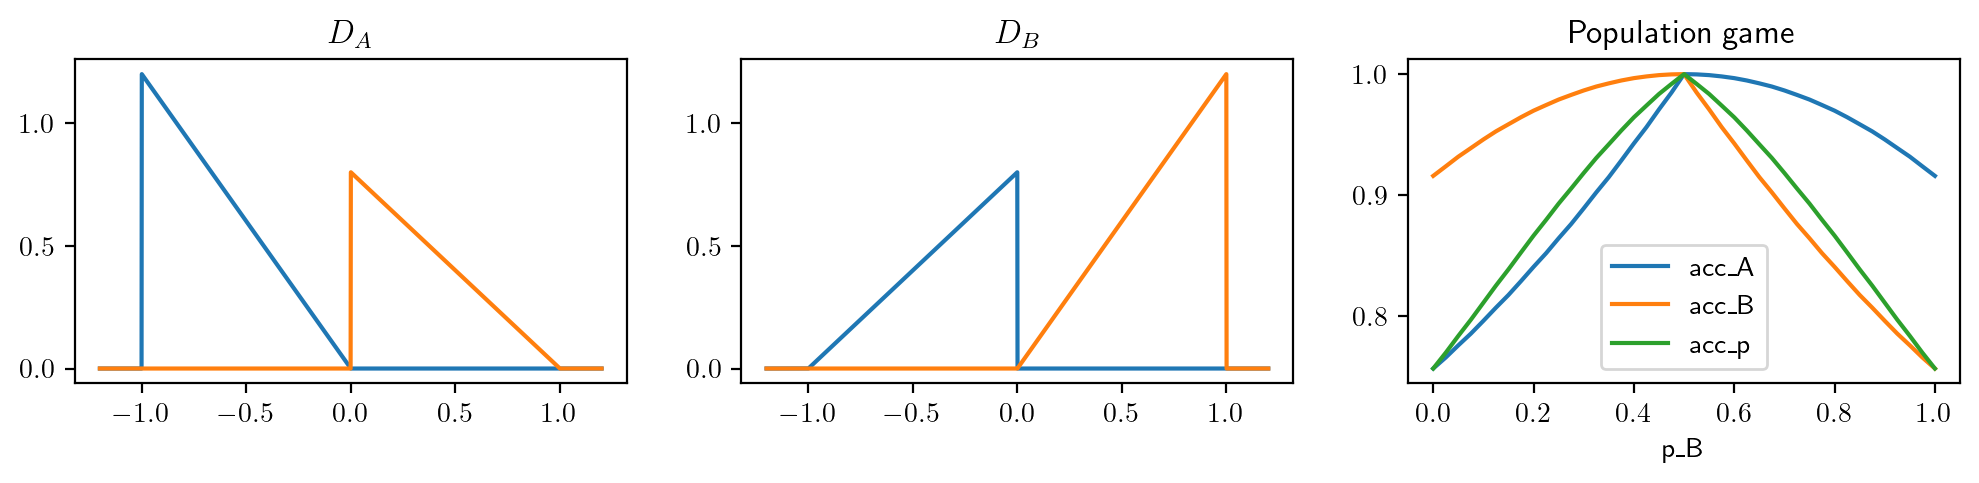

In [6]:
build_svm_pop = lambda pmaj: evoml.Population(
    groups=[
        evoml.RandomVariablePopulationGroup(
            rv_vec=[
                scipy.stats.triang(c=0,loc=-1,scale=1),
                scipy.stats.triang(c=0,loc=0,scale=1),
            ],
            p=[pmaj,1-pmaj],
        ),
        evoml.RandomVariablePopulationGroup(
            rv_vec=[
                scipy.stats.triang(c=1,loc=-1,scale=1),
                scipy.stats.triang(c=1,loc=0,scale=1),
            ],
            p=[1-pmaj,pmaj],
        ),
    ],
)
svm_pop = build_svm_pop(0.6)

x = np.linspace(-1,1,2000)*1.2
svm_x = x

svm_game_df = evoml.game.from_population_1d_rv(
    pop=svm_pop,
    clf_factory=lambda: LinearSVC(loss='hinge',penalty='l2',C=1e-3),
    # clf_factory=lambda: LinearSVC(loss='hinge',penalty='l2',C=1e-2),
    # clf_factory=lambda: LinearSVC(C=1e-3),
    x=svm_x,
    p_vec=p_vec,
)
fig,axs = evoml.create_figure(1,3,figsize=(10,2.3))
for i in [0,1]:
    axs[i].plot(svm_x,svm_pop.groups[i].pdf(x).T)
    axs[i].set_title(f'$D_{["A","B"][i]}$')

svm_game_df.iloc[:,-3:].plot.line(ax=axs[2], title='Population game')

In [7]:
results['svm'] = Result(
    mechanism='Proxy Loss',
    learner='Soft-SVM',
    population=svm_pop,
    x=svm_x,
    game=svm_game_df,
    equilibria=[
        (0.5,True),
    ]
)

svm_regularization_experiment_alpha=0.75
Figure saved as ./output/soft_svm_regularization.pdf


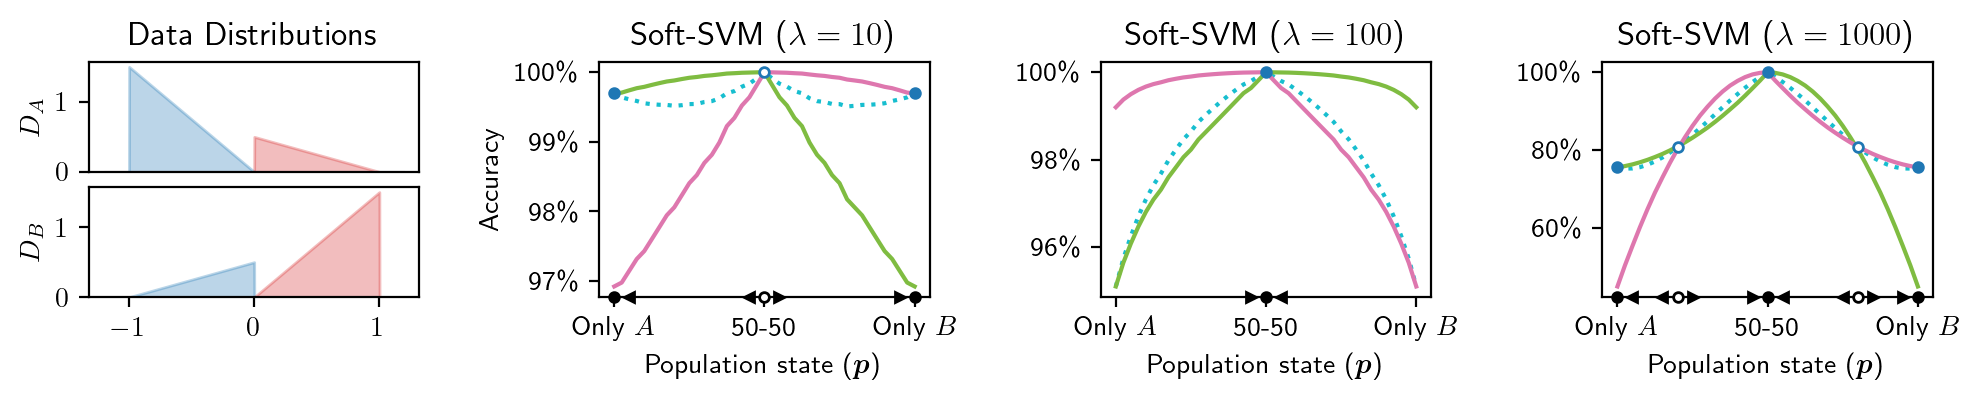

In [8]:
fig,axs = plt.subplot_mosaic(
    mosaic=[['da','c1','c2','c3'],['db','c1','c2','c3']],
    figsize=(10,1.8),
    constrained_layout=dict(
        w_pad=0.15,
        hspace=0.0,
        h_pad=0.0,
    ),
    # sharex=True,
    # width_ratios=[1,1,0.5,1],
)

svm_C_pop = build_svm_pop(param(0.75,'svm_regularization_experiment_alpha'))



for ax,C,eq in zip(
    [axs['c1'],axs['c2'],axs['c3']],
    [1e-1,1e-2,1e-3],
    [
        [(0.0,True),(0.5,False),(1.0,True)],
        [(0.5,True)],
        [(0.0,True),(0.2,False),(0.5,True),(0.8,False),(1.0,True)],
    ]
):
    evoml.plot_population_game(
        game_df=evoml.game.from_population_1d_rv(
            pop=svm_C_pop,
            clf_factory=lambda: LinearSVC(loss='hinge',penalty='l2',C=C),
            x=svm_x,
            p_vec=p_vec,
        ),
        ax=ax,
        equilibria=eq,
    )
    ax.set(
        title=f'Soft-SVM ($\\lambda={1/C:.0f}$)',
    )
    if C<1e-1:
        ax.set(
            ylabel=None,
        )
    ax.yaxis.set_major_formatter(
        matplotlib.ticker.PercentFormatter(xmax=1,decimals=0),
    )

axs['da'].get_xaxis().set_visible(False)
plot_1d_dist(
    ax=axs['da'],
    x=x,
    f=svm_C_pop.mixture_pdf(x,p=[1,0]),
)
axs['da'].set(
    title='Data Distributions',
    ylabel='$D_A$',
)
plot_1d_dist(
    ax=axs['db'],
    x=x,
    f=svm_C_pop.mixture_pdf(x,p=[0,1]),
)
axs['db'].set(
    ylabel='$D_B$',
)
evoml.analysis.save_and_download_fig(fig, './output/soft_svm_regularization.pdf', bbox_inches='tight')

## k-NN

In [9]:
def knn_groups(alpha, beta):
    d = 0.6
    w = 0.6
    a = b = 5
    pos = scipy.stats.beta(a,b,loc=d/2,scale=w)
    neg = scipy.stats.beta(a,b,loc=-d/2-w,scale=w)
    return [
        evoml.RandomVariablePopulationGroup(
            rv_vec=[
                evoml.MixtureRandomVariable(
                    rv_vec=[
                        neg,
                        pos,
                    ],
                    p=[
                        (1-beta)/(1-beta+beta*alpha),
                        (beta*alpha)/(1-beta+beta*alpha),
                    ],
                ),
                pos,
            ],
            p = [
                1-beta*(1-alpha),
                beta*(1-alpha),
            ]
        ),
        evoml.RandomVariablePopulationGroup(
            rv_vec=[
                neg,
                evoml.MixtureRandomVariable(
                    rv_vec=[
                        pos,
                        neg,
                    ],
                    p=[
                        (1-beta)/(1-beta+beta*alpha),
                        (beta*alpha)/(1-beta+beta*alpha),
                    ],
                ),
            ],
            p = [
                beta*(1-alpha),
                1-beta*(1-alpha),
            ]
        ),
    ]

knn_pop = evoml.Population(
    groups=knn_groups(
        alpha=0.2,
        beta=0.8,
    )
)

knn_x = x


In [10]:
knn_game_df = evoml.game.from_population_sample(
    pop=knn_pop,
    clf_factory=lambda: KNeighborsClassifier(n_neighbors=1),
    p_vec=p_vec,
    n_train=100,
    n_test=100,
    n_reps=2000,
    random_state=random_state,
)

Population game:   0%|          | 0/41 [00:00<?, ?it/s]

<Axes: xlabel='p_B'>

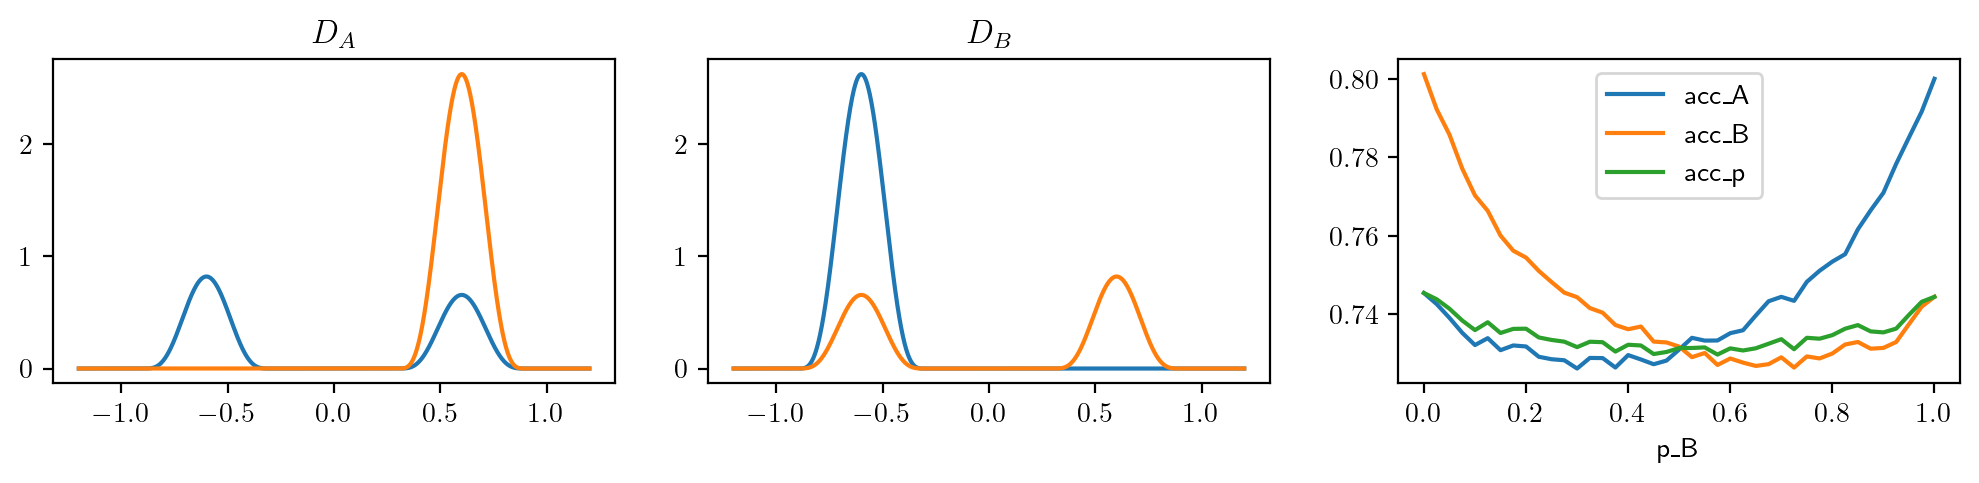

In [11]:
fig,axs = evoml.create_figure(1,3,figsize=(10,2.3))
for i in [0,1]:
    axs[i].plot(knn_x,knn_pop.groups[i].pdf(knn_x).T)
    axs[i].set_title(f'$D_{["A","B"][i]}$')

knn_game_df.iloc[:,-3:].groupby(level=0).mean().plot.line(ax=axs[2])

In [12]:
results['knn'] = Result(
    mechanism='Interpolation',
    learner='1-NN',
    population=knn_pop,
    x=knn_x,
    game=knn_game_df,
    equilibria=[
        (0.5,True),
    ],
)

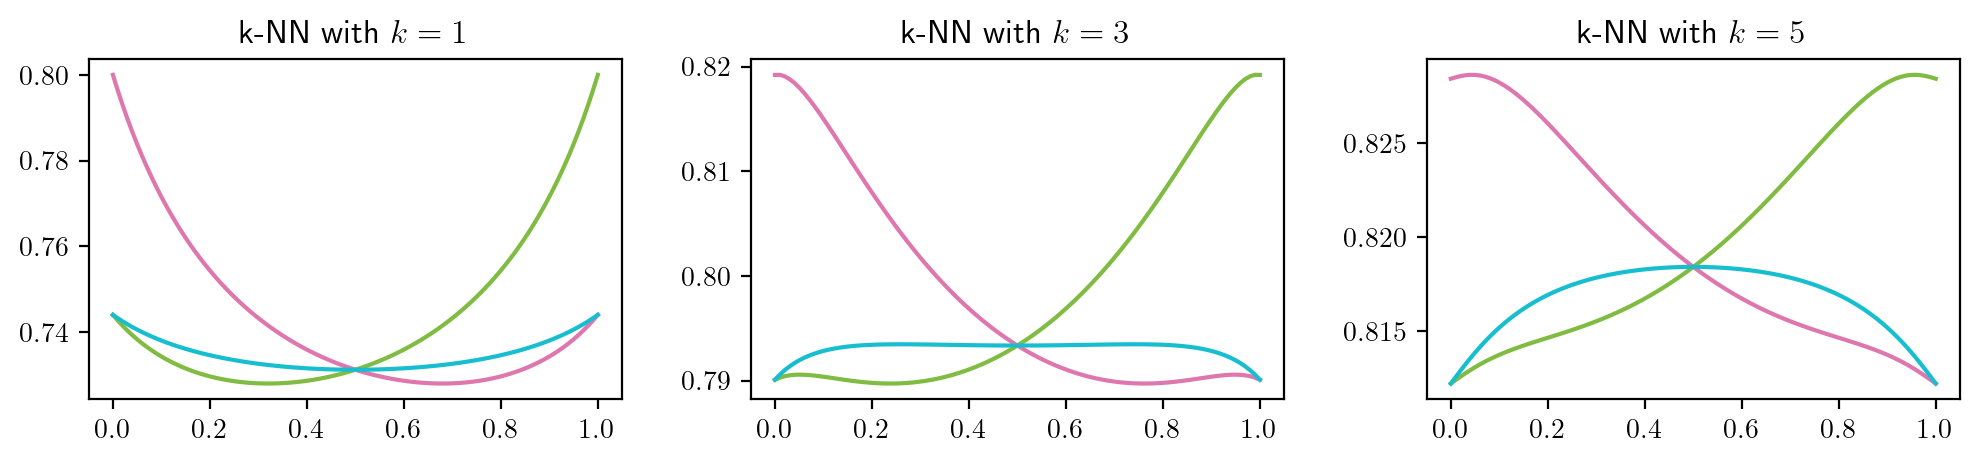

In [13]:
k_vec = [1,3,5]

fig,axs=evoml.create_figure(
    1,3,
    figsize=(10,2.2),
    # sharey=True,
)

alpha = 0.2
beta = 0.8

for k,ax in zip(k_vec,axs):
    ## Theory
    p = np.linspace(0,1,100)
    binom_cdf = lambda p: scipy.stats.binom.cdf(n=k,k=k//2,p=p)
    gamma = p - 2*p*beta + beta
    noise_coeff_pos = beta*(1-p)/gamma
    noise_coeff_neg = beta*p/(1-gamma)
    # exp_yhat_pos = 1-2*binom_cdf(1-noise_coeff_pos*alpha)
    # exp_yhat_neg = -1+2*binom_cdf(1-noise_coeff_neg*alpha)
    exp_yhat_pos = -1+2*binom_cdf(noise_coeff_pos*alpha)
    exp_yhat_neg = 1-2*binom_cdf(noise_coeff_neg*alpha)
    acc_pos = (1+(1-2*alpha)*exp_yhat_pos)/2
    acc_neg = (1+(-1)*exp_yhat_neg)/2
    acc_A = beta*acc_pos + (1-beta)*acc_neg
    acc_B = acc_A[::-1]
    line_params = {
        # 'linestyle': '--',
        'zorder': -1,
        # 'alpha': 0.4,
    }
    ax.plot(p, acc_A, label='acc_A',color=evoml.group_colors[0], **line_params)
    ax.plot(p, acc_B, label='acc_B',color=evoml.group_colors[1], **line_params)
    ax.plot(p, (1-p)*acc_A+p*acc_B, color='tab:cyan', **line_params)
    ax.set_title(f'k-NN with $k={k}$')
    

## Hard-SVM

In [14]:
def hardsvm_groups():
    w = 0.2
    pmaj = 0.5
    return [
        evoml.RandomVariablePopulationGroup(
            rv_vec=[
                scipy.stats.uniform(-w,w),
                scipy.stats.uniform(0,1),
            ],
            p=[1-pmaj,pmaj],
            
        ),
        evoml.RandomVariablePopulationGroup(
            rv_vec=[
                scipy.stats.uniform(-1,1),
                scipy.stats.uniform(0,w),
            ],
            p=[pmaj,1-pmaj],
        ),
    ]

hardsvm_pop = evoml.Population(groups=hardsvm_groups())



In [15]:
hardsvm_game_df = evoml.game.from_population_sample(
    pop=hardsvm_pop,
    clf_factory=lambda: evoml.OneDimensionalHardSVM(),
    p_vec=p_vec[::2],
    n_train=20,
    n_test=200,
    # n_reps=100,
    n_reps=2000,
    random_state=random_state,
)

Population game:   0%|          | 0/21 [00:00<?, ?it/s]

<Axes: xlabel='p_B'>

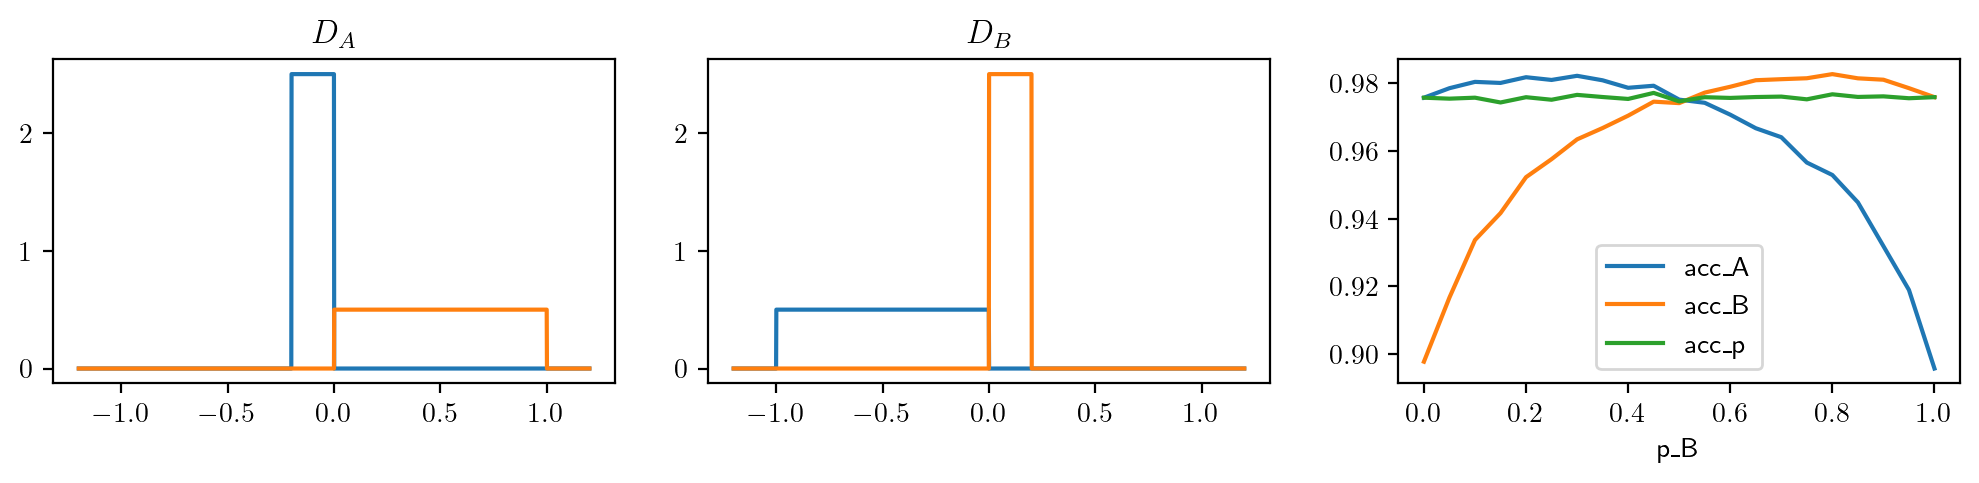

In [16]:
fig,axs = evoml.create_figure(1,3,figsize=(10,2.3))
for i in [0,1]:
    axs[i].plot(x,hardsvm_pop.groups[i].pdf(x).T)
    axs[i].set_title(f'$D_{["A","B"][i]}$')
hardsvm_game_df.iloc[:,-3:].groupby(level=0).mean().plot.line(ax=axs[2])

In [17]:
results['finite'] = Result(
    mechanism='Finite Data',
    learner='Hard-SVM',
    population=hardsvm_pop,
    x=x,
    game=hardsvm_game_df,
    equilibria=[
        (0.0,True),
        (1.0,True),
        (0.5,False),
    ],
)

## Summary

Figure saved as ./output/coexistence.pdf


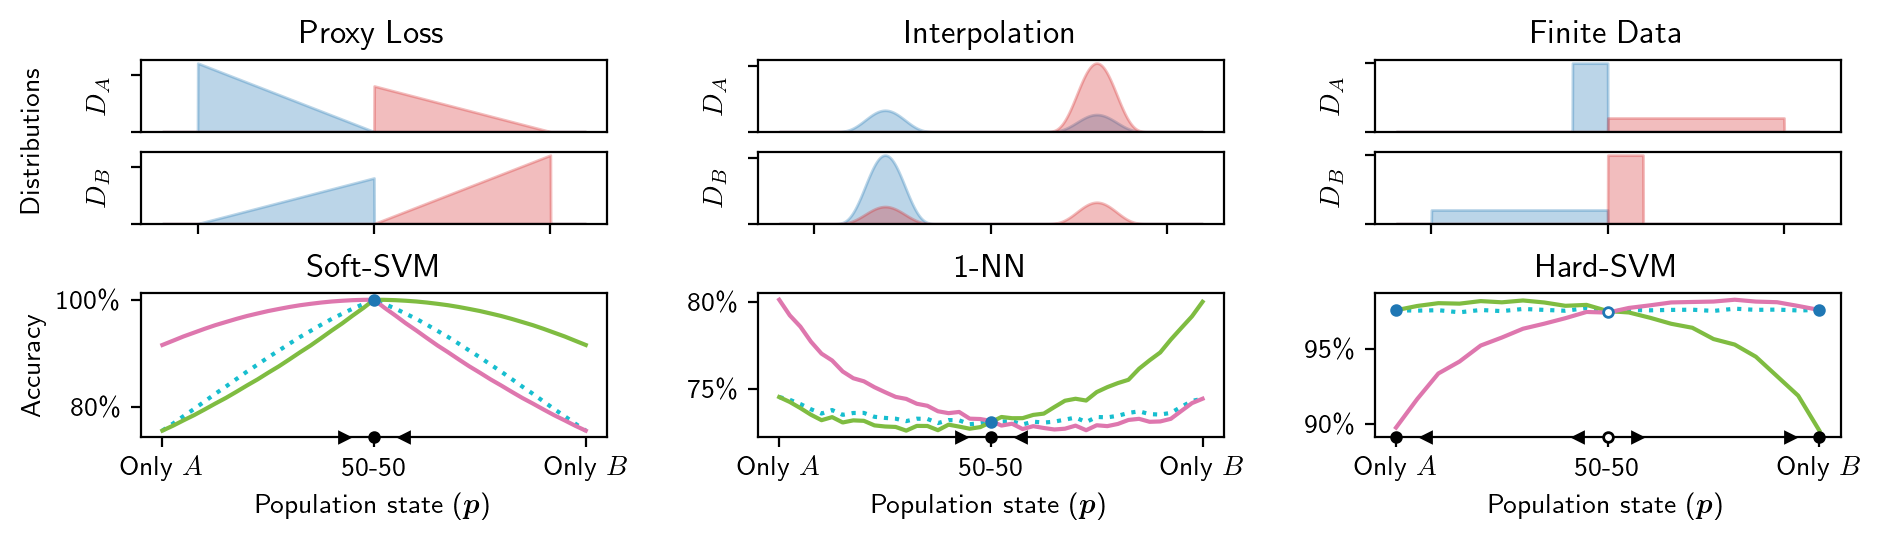

In [18]:
fig,axs=evoml.create_figure(
    3,3,
    figsize=(9.5,2.6),
    height_ratios=[1,1,2],
    constrained_layout=dict(
        w_pad=0.15,
        h_pad=0.05,
    ),
)

for ax in axs[:2].ravel():
    ax.set(
        xticklabels=[],
        yticklabels=[],
    )

for j in range(3):
    axs[0,j].set(
        ylabel='$D_A$',
    )
    axs[1,j].set(
        title=None,
        # xlabel='',
        ylabel='$D_B$',
    )

for j,res in enumerate(results.values()):
    axs[0,j].get_xaxis().set_visible(False)
    axs[0,j].set(
        title=res.mechanism,
        ylabel='$D_A$',
    )
    axs[2,j].set(
        title=res.learner,
    )
    # Plot data
    plot_1d_dist(
        ax=axs[0,j],
        x=res.x,
        f=res.population.mixture_pdf(res.x,p=[1,0]),
    )
    plot_1d_dist(
        ax=axs[1,j],
        x=res.x,
        f=res.population.mixture_pdf(res.x,p=[0,1]),
    )
    # Plot game
    evoml.plot_population_game(
        game_df=res.game,
        ax=axs[2,j],
        equilibria=res.equilibria,
        equilibria_kwargs=dict(
            d=0.07,
        )
    )
    axs[2,j].yaxis.set_major_formatter(
        matplotlib.ticker.PercentFormatter(xmax=1,decimals=0),
    )
    if j>0:
        axs[2,j].set(
            ylabel=None,
        )

fig.add_artist(matplotlib.text.Text(
    x=0.015,
    y=0.75,
    text='Distributions',
    # ha='center',
    va='center',
    rotation=90,
    fontsize=10,
))

evoml.analysis.save_and_download_fig(fig, './output/coexistence.pdf', bbox_inches='tight')

In [19]:
param_tracker.save('./output/coexistence.json')

Parameters saved as: ./output/coexistence.json
